## Linear Regression using Multiple Features

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

$charges = w_1 \times age + w_2 \times bmi + b$

We need to change just one line of code to include the BMI.

In [26]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [27]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [28]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [29]:
medical_df = pd.read_csv('medical.csv')
non_somker_df = medical_df[medical_df.smoker == 'no']

In [30]:
from sklearn.linear_model import LinearRegression

# Create inputs and targets
inputs, targets = non_somker_df[['age', 'bmi']], non_somker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute the loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [31]:
non_somker_df.charges.corr(non_somker_df.bmi)

np.float64(0.0840365431283327)

In [32]:
fig = px.scatter(non_somker_df, x='bmi', y='charges', title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

We can also visualize the relationship between all 3 variables "age", "bmi" and "charges" using a 3D scatter plot.

In [33]:
fig = px.scatter_3d(non_somker_df, x='age', y='bmi', z='charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

You can see that it's harder to interpret a 3D scatter plot compared to a 2D scatter plot. As we add more features, it becomes impossible to visualize all feature at once, which is why we use measures like correlation and loss. 

Let's also check the parameters of the model.

In [34]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

Clearly, BMI has a much lower weightage, and you can see why. It has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply. 

> **EXERCISE**: Train a linear regression model to estimate charges using BMI alone. Do you expect it to be better or worse than the previously trained models?

In [35]:
X = non_somker_df[['bmi']]
y = non_somker_df.charges

model = LinearRegression().fit(X, y)

predictions = model.predict(X)

rmse(y, predictions)

np.float64(5969.772531913293)

Let's go one step further, and add the final numeric column: "children", which seems to have some correlation with "charges".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + b$

In [36]:
non_somker_df.charges.corr(non_somker_df.children)

np.float64(0.13892870453542183)

In [37]:
fig = px.strip(non_somker_df, x='children', y='charges', title='Children vs Charges')
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [38]:
# Create inputs and targets
inputs, targets = non_somker_df[['age', 'bmi', 'children']], non_somker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# COmpute loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


Once again, we don't see a big reduction in the loss, even though it's greater than in the case of BMI.

> **EXERCISE**: Repeat the steps is this section to train a linear regression model to estimate medical charges for smokers. Visualize the targets and predictions, and compute the loss.

In [39]:
smokers_df = medical_df[medical_df.smoker == 'yes']

In [40]:
X = smokers_df[['age', 'bmi', 'children']]
y = smokers_df.charges

model = LinearRegression().fit(X, y)

predictions = model.predict(X)

loss = rmse(y, predictions)
print('Loss:', loss)

Loss: 5718.202480524154


Text(0.5, 1.0, 'Predicted vs Actual (smokers)')

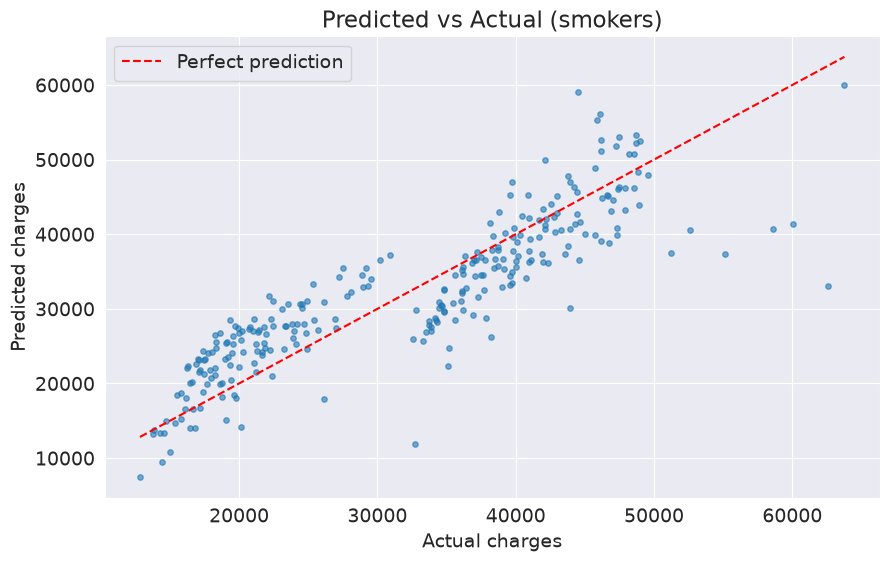

In [41]:
plt.scatter(y, predictions, alpha=0.6, s=15) # real and predicted
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction') # line of all possible charges
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.legend()
plt.title('Predicted vs Actual (smokers)')

## Predicted vs Actual Plots

**Why this plot instead of a line on a feature axis:**
With one feature, the model is a line `charges = w*age + b`, so we could plot it on a 2D axis. With multiple features (`age`, `bmi`, `children`), there's no single line to draw anymore — the prediction depends on several inputs at once. So instead we compare `actual` vs `predicted` directly, which works no matter how many features the model has.

**How to read it:**
- x-axis = real value, y-axis = predicted value, each point = one person.
- If a point falls on the diagonal, `predicted == actual` (perfect prediction).
- Farther from the line = bigger error. Above the line = overestimate, below = underestimate.

**The reference line:**
```python
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
```
`plt.plot()` just connects the given points with straight segments — 2 points fully define a line. Both points here have equal x and y (`(y.min(), y.min())` and `(y.max(), y.max())`), so they satisfy `x == y`. The line connecting them is exactly the diagonal `Y = X`, and since it spans the full range of `y`, it covers the whole scatter without needing extra points.

**The rest:**
```python
plt.scatter(y, predictions, alpha=0.6, s=15)  # actual vs predicted, one point per person
```
`alpha` = transparency (helps when points overlap), `s` = point size.

> **EXERCISE**: Repeat the steps is this section to train a linear regression model to estimate medical charges for all customers. Visualize the targets and predictions, and compute the loss. Is the loss lower or higher?

In [42]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


Let's explore how smoker affects charges

In [45]:
px.scatter(medical_df, x='age', y='charges', color='smoker')

Text(0.5, 1.0, 'Real vs Predicted')

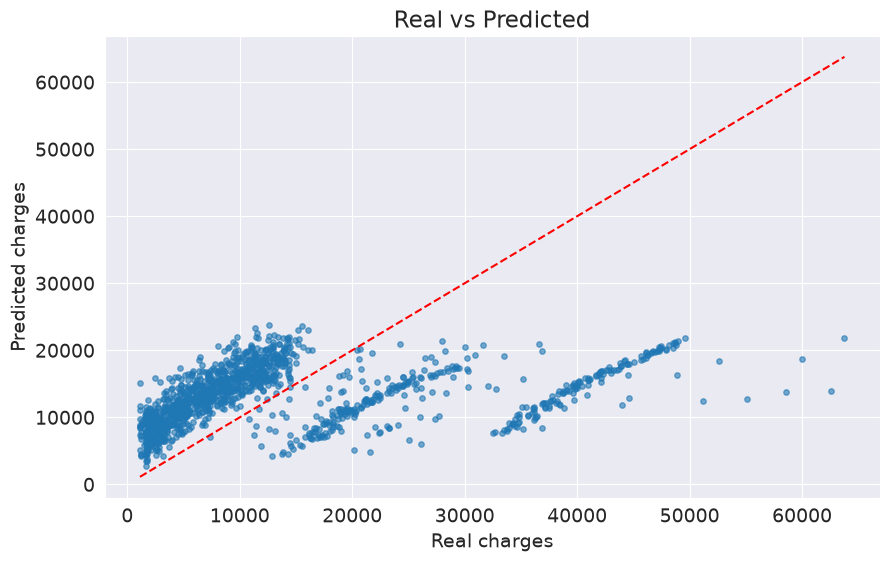

In [ ]:
plt.scatter(targets, predictions, s=15, alpha=0.6)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', label='Perfect prediction')
plt.xlabel('Real charges')
plt.ylabel('Predicted charges')
plt.title('Real vs Predicted')

## Using Categorical Features for Machine Learning

So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

1. If a categorical column has just two categories (it's called a binary category), then we can replace their values with 0 and 1.
2. If a categorical column has more than 2 categories, we can perform one-hot encoding i.e. create a new column for each category with 1s and 0s.
3. If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called ordinals

